In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\D.Sagar\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


### Step 1: Data Collection & Loading

In [2]:
df=pd.read_csv("./mental_tiredness_score_prediction_dataset.csv.csv")

In [3]:
df.head()

,number_of_decisions_made,context_switch_count,notifications_received,screen_time_min,deep_work_min,task_complexity_avg,caffeine_mg,break_frequency,sleep_hours,deep_sleep_pct,hydration_l,mood,work_type,work_environment,noise_level_db,temperature_c,workload_score,mental_tiredness_score
0,110,14,70,196.5,65.1,7.0,136.1,1,7.84,26.75,2.05,Happy,Remote,Moderate Noise,53.8,19.8,3.3,22.17
1,122,9,66,256.4,135.2,6.5,83.9,3,7.18,17.82,1.82,Low,Remote,Noisy,38.9,18.7,4.6,25.35
2,113,4,55,387.3,54.2,10.0,176.5,5,5.52,27.78,1.92,Happy,Office,Quiet,42.0,26.4,7.9,34.36
3,113,8,45,300.3,107.1,4.8,164.7,2,8.47,3.48,1.89,Happy,Manual,Quiet,47.2,23.8,5.4,11.92
4,95,8,68,240.5,3.2,8.0,186.3,4,7.48,21.17,2.41,Happy,Manual,Moderate Noise,61.0,24.2,8.5,37.45


In [4]:
df.shape

(15000, 18)

In [5]:
df.size

270000

In [6]:
len(df)

15000

### Step 2: Initial Data Inspection

In [7]:
df.head()

,number_of_decisions_made,context_switch_count,notifications_received,screen_time_min,deep_work_min,task_complexity_avg,caffeine_mg,break_frequency,sleep_hours,deep_sleep_pct,hydration_l,mood,work_type,work_environment,noise_level_db,temperature_c,workload_score,mental_tiredness_score
0,110,14,70,196.5,65.1,7.0,136.1,1,7.84,26.75,2.05,Happy,Remote,Moderate Noise,53.8,19.8,3.3,22.17
1,122,9,66,256.4,135.2,6.5,83.9,3,7.18,17.82,1.82,Low,Remote,Noisy,38.9,18.7,4.6,25.35
2,113,4,55,387.3,54.2,10.0,176.5,5,5.52,27.78,1.92,Happy,Office,Quiet,42.0,26.4,7.9,34.36
3,113,8,45,300.3,107.1,4.8,164.7,2,8.47,3.48,1.89,Happy,Manual,Quiet,47.2,23.8,5.4,11.92
4,95,8,68,240.5,3.2,8.0,186.3,4,7.48,21.17,2.41,Happy,Manual,Moderate Noise,61.0,24.2,8.5,37.45


In [8]:
df.tail()

,number_of_decisions_made,context_switch_count,notifications_received,screen_time_min,deep_work_min,task_complexity_avg,caffeine_mg,break_frequency,sleep_hours,deep_sleep_pct,hydration_l,mood,work_type,work_environment,noise_level_db,temperature_c,workload_score,mental_tiredness_score
14995,132,14,69,207.9,162.3,6.8,51.8,4,4.58,5.83,1.29,Low,Remote,Noisy,46.0,21.6,6.6,48.53
14996,111,11,49,365.2,69.4,7.7,67.0,1,7.39,18.18,1.65,Low,Student,Moderate Noise,42.0,26.0,6.6,50.75
14997,108,7,66,405.5,54.0,3.8,0.0,7,7.22,15.83,2.11,Low,Remote,Quiet,39.5,23.4,3.5,9.61
14998,143,8,64,402.8,18.2,3.0,0.0,5,7.89,16.72,0.38,Low,Office,Moderate Noise,54.4,27.1,6.0,32.05
14999,119,12,75,262.5,104.9,6.0,246.8,2,8.26,26.08,3.15,Neutral,Student,Quiet,27.5,22.2,2.8,8.97


In [9]:
df.describe()

,number_of_decisions_made,context_switch_count,notifications_received,screen_time_min,deep_work_min,task_complexity_avg,caffeine_mg,break_frequency,sleep_hours,deep_sleep_pct,hydration_l,noise_level_db,temperature_c,workload_score,mental_tiredness_score
count,15000.000000,15000.000000,15000.00000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,120.079133,7.982133,64.96780,302.211107,96.698407,5.505333,131.170247,4.001733,6.893889,19.017639,1.892743,47.925353,23.000160,5.697280,25.189109
std,10.882327,2.837784,8.11442,136.575167,61.249273,1.957174,79.542710,2.017358,1.296186,5.958026,0.686356,9.880337,2.967518,1.941123,12.190013
min,82.000000,0.000000,30.00000,20.000000,0.000000,1.000000,0.000000,0.000000,3.000000,0.000000,0.300000,20.000000,15.000000,1.000000,0.000000
25%,113.000000,6.000000,59.00000,205.300000,50.100000,4.175000,72.200000,3.000000,6.010000,15.040000,1.430000,41.300000,21.000000,4.400000,16.690000
50%,120.000000,8.000000,65.00000,302.000000,94.800000,5.500000,129.000000,4.000000,6.900000,18.980000,1.890000,47.900000,23.000000,5.700000,25.220000
75%,127.000000,10.000000,70.00000,396.100000,138.800000,6.800000,185.500000,5.000000,7.780000,23.062500,2.350000,54.600000,25.000000,7.000000,33.460000
max,165.000000,21.000000,101.00000,852.200000,312.800000,10.000000,422.900000,13.000000,11.000000,41.380000,4.570000,84.800000,35.000000,10.000000,76.740000


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   number_of_decisions_made  15000 non-null  int64  
 1   context_switch_count      15000 non-null  int64  
 2   notifications_received    15000 non-null  int64  
 3   screen_time_min           15000 non-null  float64
 4   deep_work_min             15000 non-null  float64
 5   task_complexity_avg       15000 non-null  float64
 6   caffeine_mg               15000 non-null  float64
 7   break_frequency           15000 non-null  int64  
 8   sleep_hours               15000 non-null  float64
 9   deep_sleep_pct            15000 non-null  float64
 10  hydration_l               15000 non-null  float64
 11  mood                      15000 non-null  str    
 12  work_type                 15000 non-null  str    
 13  work_environment          15000 non-null  str    
 14  noise_level_db   

In [11]:
df.isna().sum()

number_of_decisions_made    0
context_switch_count        0
notifications_received      0
screen_time_min             0
deep_work_min               0
task_complexity_avg         0
caffeine_mg                 0
break_frequency             0
sleep_hours                 0
deep_sleep_pct              0
hydration_l                 0
mood                        0
work_type                   0
work_environment            0
noise_level_db              0
temperature_c               0
workload_score              0
mental_tiredness_score      0
dtype: int64

In [12]:
df.columns

Index(['number_of_decisions_made', 'context_switch_count',
       'notifications_received', 'screen_time_min', 'deep_work_min',
       'task_complexity_avg', 'caffeine_mg', 'break_frequency', 'sleep_hours',
       'deep_sleep_pct', 'hydration_l', 'mood', 'work_type',
       'work_environment', 'noise_level_db', 'temperature_c', 'workload_score',
       'mental_tiredness_score'],
      dtype='str')

In [13]:
for i in df.columns:
    print(f"{i}:-\n\n{df[i].unique()}")

number_of_decisions_made:-

[110 122 113  95 126  86 111 107 119 135 121 112 142 133 116 123 108 120
 104 131 127 140 136 141 114 124 139 118 144 117 109 130 132 125 128 134
 115 154 146  99 102 100 129 148 105  96 145 156 103 143 138 106  98  97
 137 101  93 153 147  91  87  94  88 149 150  84  92  90 164 152 157 158
 155  89  83 163  82 151 159 165  85 162]
context_switch_count:-

[14  9  4  8  7  6 12  5 10  3 11  2 13 16 15 17 18  1 19  0 21 20]
notifications_received:-

[ 70  66  55  45  68  67  65  75  61  83  85  58  56  51  64  59  76  77
  79  71  53  62  57  54  49  69  46  60  52  73  43  47  72  74  81  78
  63  95  93  50  89  48  42  87  44  80  84  82  92  41  90  39  91  86
  88  40  97  37 101  99  30  31  94]
screen_time_min:-

[196.5 256.4 387.3 ...  26.6 117.1 206.5]
deep_work_min:-

[ 65.1 135.2  54.2 ... 231.2 238.3 246.6]
task_complexity_avg:-

[ 7.   6.5 10.   4.8  8.   5.1  2.3  1.7  6.1  4.2  4.7  3.2  5.   7.2
  5.5  4.4  7.7  7.8  2.8  5.3  7.3  5.2  6.3  4.

In [14]:
df.duplicated().sum()

np.int64(0)

###   Step 3: Data Cleaning

- `As the data does not have any duplicates and null values no need to clean`
- `All the datatypes and data names are correct and standardized`

###   Step 4: Exploratory Data Analysis (EDA)

#### Univariate Analysis

In [15]:
df.head()

,number_of_decisions_made,context_switch_count,notifications_received,screen_time_min,deep_work_min,task_complexity_avg,caffeine_mg,break_frequency,sleep_hours,deep_sleep_pct,hydration_l,mood,work_type,work_environment,noise_level_db,temperature_c,workload_score,mental_tiredness_score
0,110,14,70,196.5,65.1,7.0,136.1,1,7.84,26.75,2.05,Happy,Remote,Moderate Noise,53.8,19.8,3.3,22.17
1,122,9,66,256.4,135.2,6.5,83.9,3,7.18,17.82,1.82,Low,Remote,Noisy,38.9,18.7,4.6,25.35
2,113,4,55,387.3,54.2,10.0,176.5,5,5.52,27.78,1.92,Happy,Office,Quiet,42.0,26.4,7.9,34.36
3,113,8,45,300.3,107.1,4.8,164.7,2,8.47,3.48,1.89,Happy,Manual,Quiet,47.2,23.8,5.4,11.92
4,95,8,68,240.5,3.2,8.0,186.3,4,7.48,21.17,2.41,Happy,Manual,Moderate Noise,61.0,24.2,8.5,37.45


In [16]:
df["number_of_decisions_made"].skew()

np.float64(0.06393663199561075)

In [17]:
df["context_switch_count"].skew()

np.float64(0.36950696744562556)

number_of_decisions_made:-
0.06393663199561075

Axes(0.125,0.11;0.775x0.77)
context_switch_count:-
0.36950696744562556

Axes(0.125,0.11;0.775x0.77)
notifications_received:-
0.10421238937006329

Axes(0.125,0.11;0.775x0.77)
screen_time_min:-
0.11907096299148887

Axes(0.125,0.11;0.775x0.77)
deep_work_min:-
0.29826119372454624

Axes(0.125,0.11;0.775x0.77)
task_complexity_avg:-
-0.016845177707498812

Axes(0.125,0.11;0.775x0.77)
caffeine_mg:-
0.2662188317196601

Axes(0.125,0.11;0.775x0.77)
break_frequency:-
0.4951191937880155

Axes(0.125,0.11;0.775x0.77)
sleep_hours:-
-0.014785859084416847

Axes(0.125,0.11;0.775x0.77)
deep_sleep_pct:-
0.026629627337059234

Axes(0.125,0.11;0.775x0.77)
hydration_l:-
0.061898874730868324

Axes(0.125,0.11;0.775x0.77)
noise_level_db:-
-0.004253224178580761

Axes(0.125,0.11;0.775x0.77)
temperature_c:-
0.012999008470217135

Axes(0.125,0.11;0.775x0.77)
workload_score:-
-0.03392486363430092

Axes(0.125,0.11;0.775x0.77)
mental_tiredness_score:-
0.10772558596109118

Ax

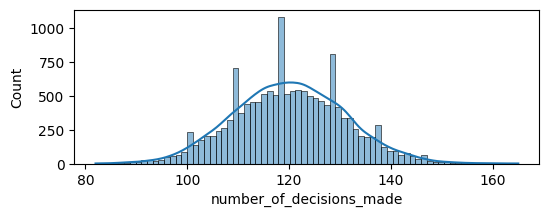

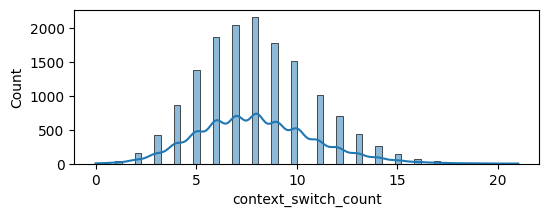

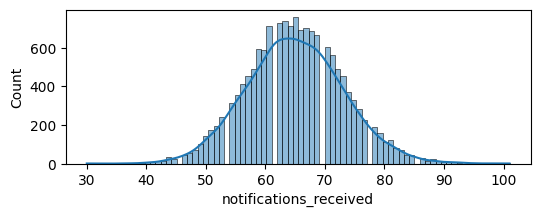

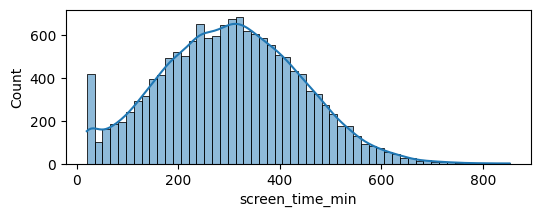

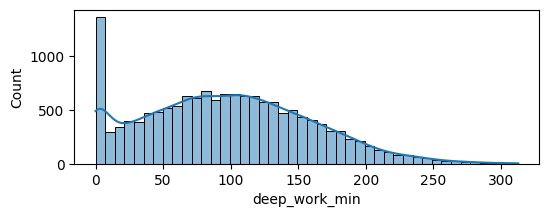

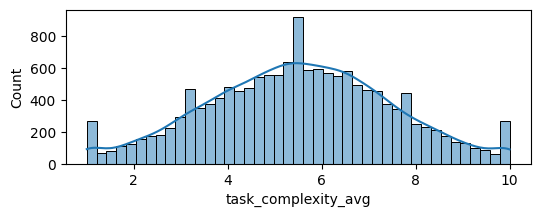

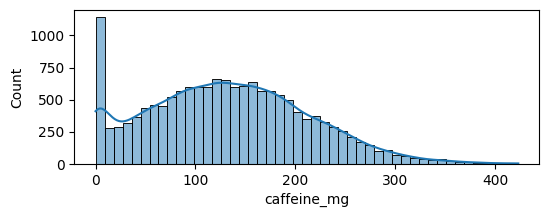

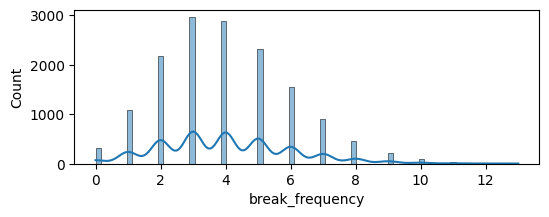

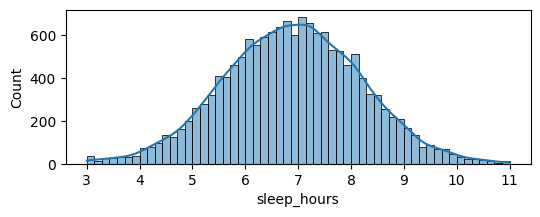

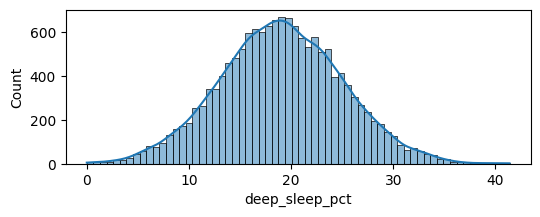

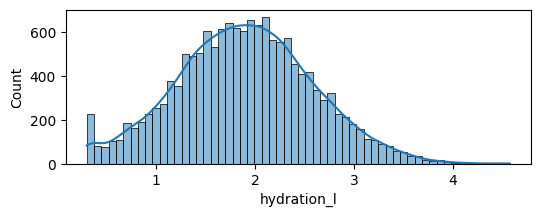

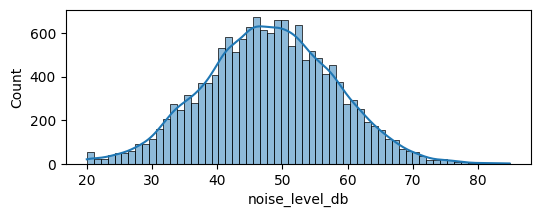

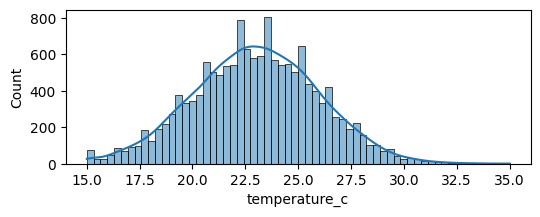

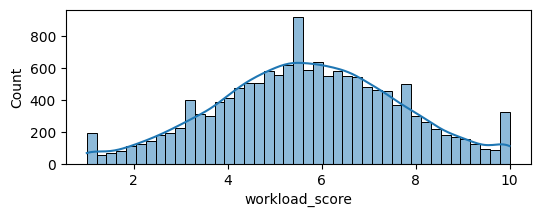

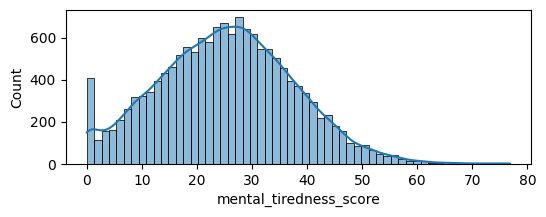

In [18]:
#Skewness_calcuclation
num=df.select_dtypes(include = ['int','float'])
for i in num.columns:
    print(f"{i}:-\n{num[i].skew()}\n")
    plt.figure(figsize=(6,2))
    print(sns.histplot(df[i],kde=True))

#### Bivariate Analysis

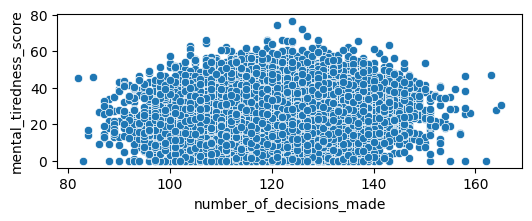

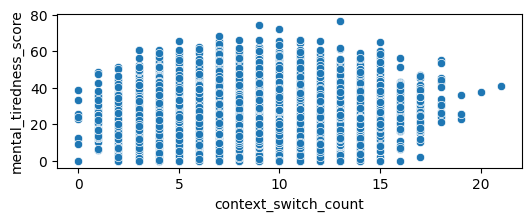

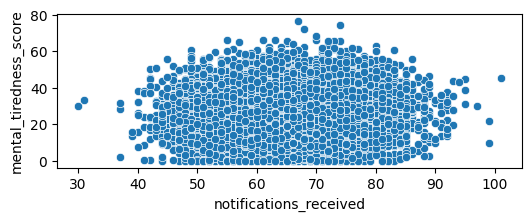

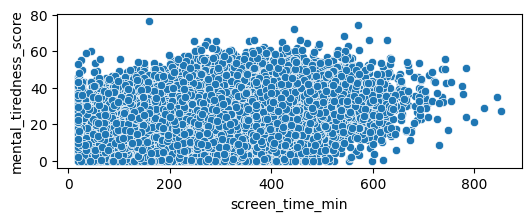

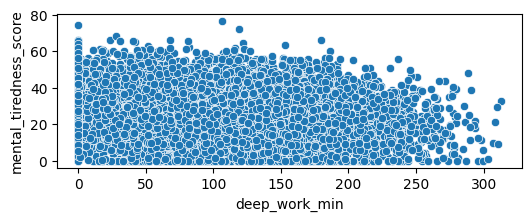

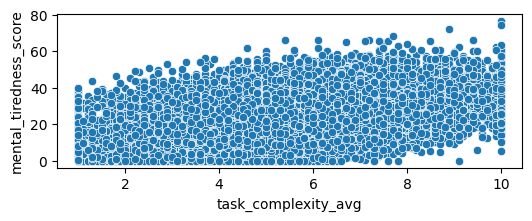

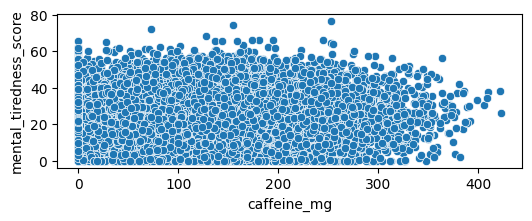

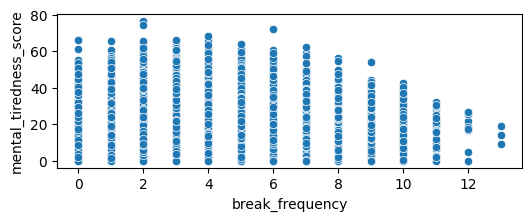

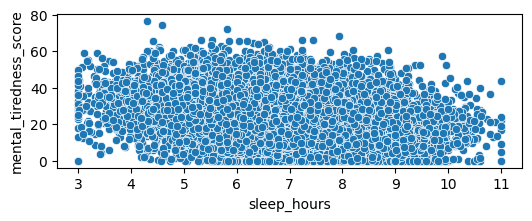

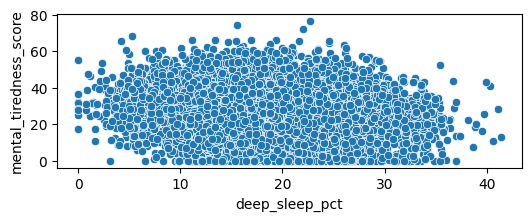

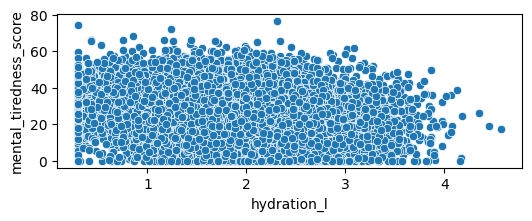

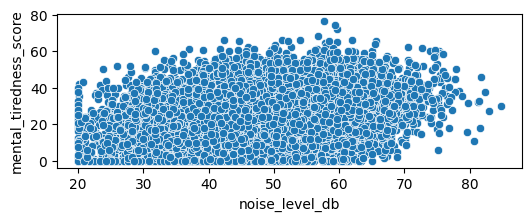

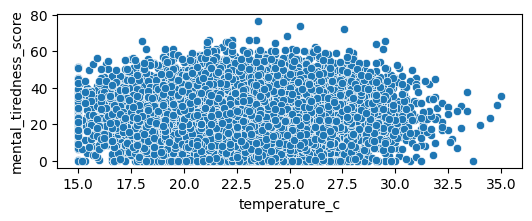

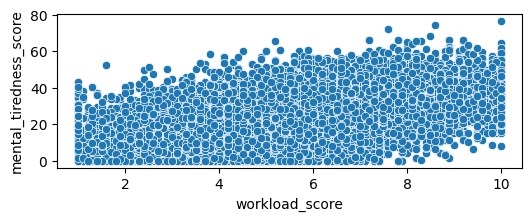

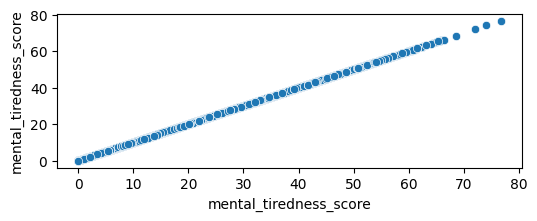

In [19]:
for i in num:
    plt.figure(figsize=(6,2))
    sns.scatterplot(x=df[i],y=df["mental_tiredness_score"])

<Axes: xlabel='work_environment', ylabel='mental_tiredness_score'>

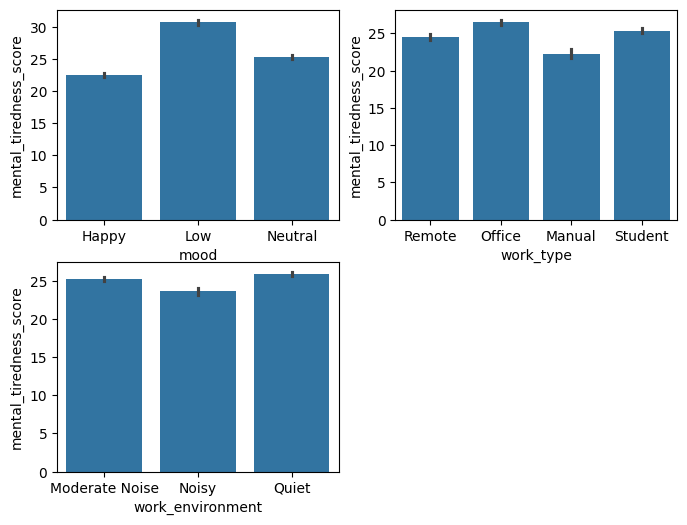

In [20]:
plt.figure(figsize=(8,6))
plt.subplot(2,2,1)
sns.barplot(x=df["mood"],y=df["mental_tiredness_score"])
plt.subplot(2,2,2)
sns.barplot(x=df["work_type"],y=df["mental_tiredness_score"])
plt.subplot(2,2,3)
sns.barplot(x=df["work_environment"],y=df["mental_tiredness_score"])


<Axes: >

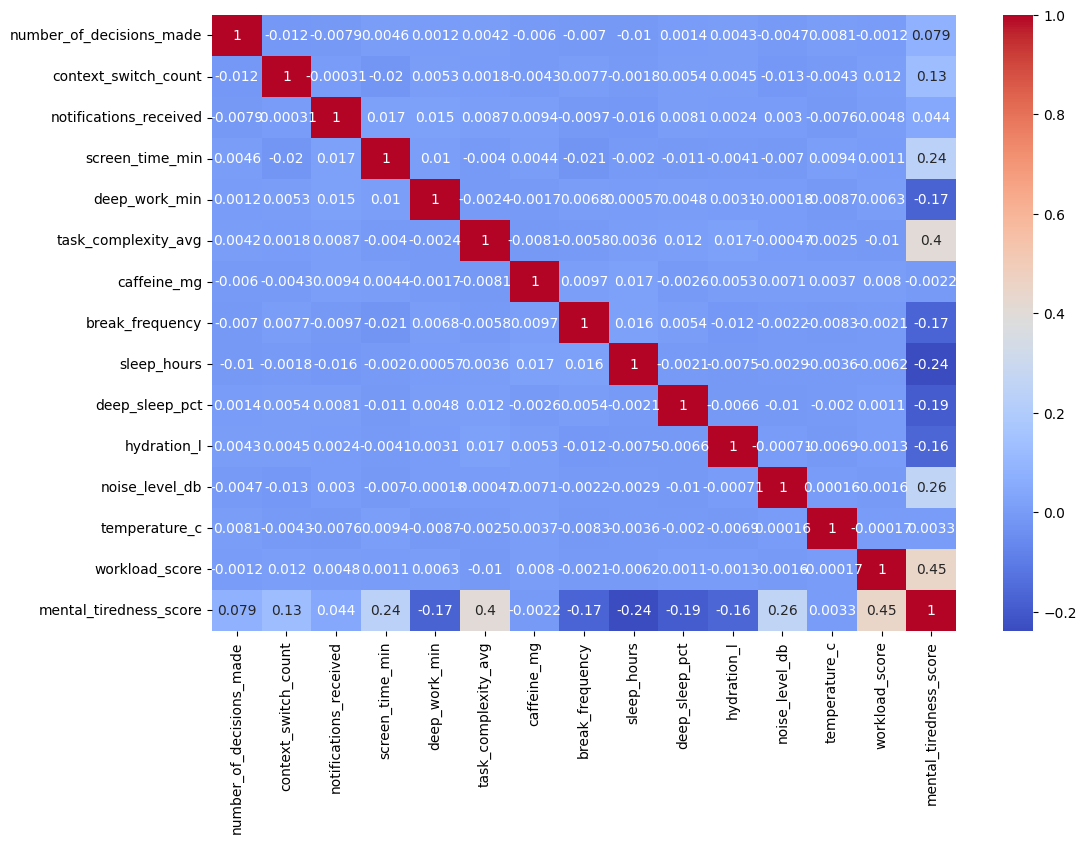

In [21]:
corr=df.corr(numeric_only=True)
plt.figure(figsize=(12,8))
sns.heatmap(corr,annot=True,cmap='coolwarm')

- `'screen_time_min','task_complexity_avg','noise_level_db','workload_score' These columns `
`has high correlation value compared to others so affect of these columns is high`

###   Step 5: Outlier Detection & Treatment

In [22]:
imp_cols=['screen_time_min','task_complexity_avg','noise_level_db','workload_score']

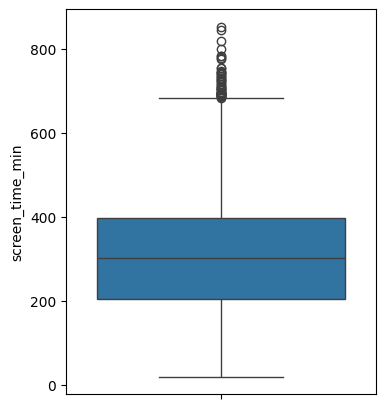

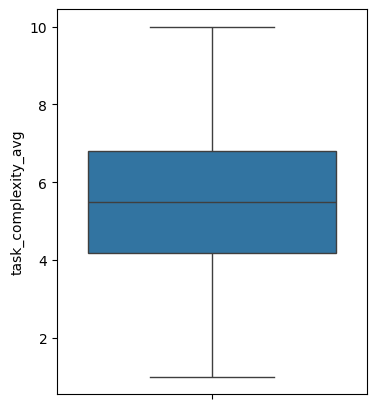

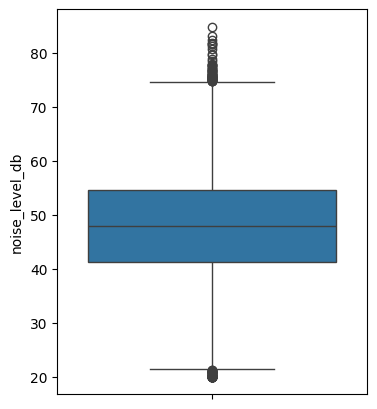

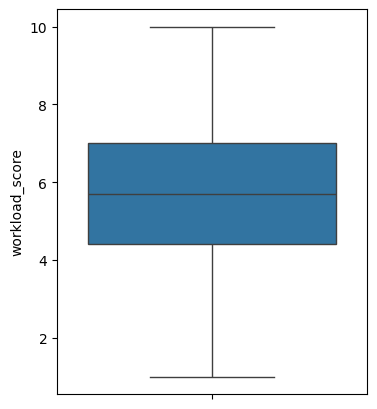

In [23]:
for i in imp_cols:
    plt.figure(figsize=(4,5))
    sns.boxplot(df[i])

- `'screen_time_min' and 'noise_level_db' has outliers'`

In [24]:
q1 = df['screen_time_min'].quantile(0.25)
q3 = df['screen_time_min'].quantile(0.75)
iqr = q3 - q1

In [25]:
lb = q1 - 1.5 * iqr
ub = q3 + 1.5 * iqr
print(f"Lower_boundary= {lb}\nUpper_boundary= {ub}")

Lower_boundary= -80.90000000000003
Upper_boundary= 682.3000000000001


In [26]:
#Outliers
df[(df['screen_time_min']<lb) | (df['screen_time_min']>ub)]

,number_of_decisions_made,context_switch_count,notifications_received,screen_time_min,deep_work_min,task_complexity_avg,caffeine_mg,break_frequency,sleep_hours,deep_sleep_pct,hydration_l,mood,work_type,work_environment,noise_level_db,temperature_c,workload_score,mental_tiredness_score
59,123,7,60,688.3,250.4,5.7,52.5,1,5.89,13.40,1.84,Low,Remote,Moderate Noise,58.7,23.7,8.8,45.64
509,113,7,64,708.7,110.1,3.8,8.9,3,7.75,23.25,0.53,Low,Remote,Quiet,40.1,27.5,6.0,31.50
641,121,6,56,682.7,127.9,6.1,290.4,3,8.62,12.69,0.63,Happy,Manual,Moderate Noise,63.0,28.7,6.8,35.35
1361,117,2,63,695.2,129.6,4.5,128.7,7,7.29,17.76,1.29,Low,Student,Moderate Noise,38.0,25.2,8.4,32.85
1979,124,8,76,710.4,28.2,6.0,286.1,4,8.10,18.13,0.66,Neutral,Student,Quiet,49.7,24.0,6.4,47.10
2674,125,9,75,695.0,21.4,8.4,1.2,3,6.84,13.54,0.88,Happy,Manual,Noisy,37.8,21.5,4.5,44.31
2874,122,11,66,741.5,169.7,7.4,50.7,5,5.42,10.75,1.29,Happy,Office,Quiet,43.1,27.8,6.0,55.56
2949,130,8,51,743.9,120.4,3.8,127.7,2,7.94,17.65,1.65,Neutral,Student,Moderate Noise,64.3,23.5,9.4,42.48
3118,123,10,76,783.1,67.8,4.2,164.9,6,8.50,20.71,1.71,Happy,Student,Noisy,63.9,26.3,4.5,23.95
3337,115,8,51,735.6,162.2,3.9,63.4,4,7.27,18.31,1.26,Happy,Student,Noisy,58.3,23.2,3.3,34.92


In [27]:
df[df['screen_time_min']<lb]

,number_of_decisions_made,context_switch_count,notifications_received,screen_time_min,deep_work_min,task_complexity_avg,caffeine_mg,break_frequency,sleep_hours,deep_sleep_pct,hydration_l,mood,work_type,work_environment,noise_level_db,temperature_c,workload_score,mental_tiredness_score


In [28]:
df.loc[df['screen_time_min'] > ub, 'screen_time_min'] = int(ub)
df.loc[df['screen_time_min'] > ub, 'screen_time_min']

Series([], Name: screen_time_min, dtype: float64)

In [29]:
df.loc[df['screen_time_min'] < lb, 'screen_time_min'] 

Series([], Name: screen_time_min, dtype: float64)

In [30]:
df[(df['screen_time_min']<lb) | (df['screen_time_min']>ub)]

,number_of_decisions_made,context_switch_count,notifications_received,screen_time_min,deep_work_min,task_complexity_avg,caffeine_mg,break_frequency,sleep_hours,deep_sleep_pct,hydration_l,mood,work_type,work_environment,noise_level_db,temperature_c,workload_score,mental_tiredness_score


In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   number_of_decisions_made  15000 non-null  int64  
 1   context_switch_count      15000 non-null  int64  
 2   notifications_received    15000 non-null  int64  
 3   screen_time_min           15000 non-null  float64
 4   deep_work_min             15000 non-null  float64
 5   task_complexity_avg       15000 non-null  float64
 6   caffeine_mg               15000 non-null  float64
 7   break_frequency           15000 non-null  int64  
 8   sleep_hours               15000 non-null  float64
 9   deep_sleep_pct            15000 non-null  float64
 10  hydration_l               15000 non-null  float64
 11  mood                      15000 non-null  str    
 12  work_type                 15000 non-null  str    
 13  work_environment          15000 non-null  str    
 14  noise_level_db   

In [32]:
q1 = df['noise_level_db'].quantile(0.25)
q3 = df['noise_level_db'].quantile(0.75)
iqr = q3 - q1

In [33]:
lb = q1 - 1.5 * iqr
ub = q3 + 1.5 * iqr
print(f"Lower_boundary= {lb}\nUpper_boundary= {ub}")

Lower_boundary= 21.34999999999999
Upper_boundary= 74.55000000000001


In [34]:
#Outliers
df[(df['noise_level_db']<lb) | (df['noise_level_db']>ub)]

,number_of_decisions_made,context_switch_count,notifications_received,screen_time_min,deep_work_min,task_complexity_avg,caffeine_mg,break_frequency,sleep_hours,deep_sleep_pct,hydration_l,mood,work_type,work_environment,noise_level_db,temperature_c,workload_score,mental_tiredness_score
193,124,8,59,245.4,171.8,3.7,185.4,0,8.39,20.18,2.47,Neutral,Student,Moderate Noise,20.7,27.0,4.4,0.00
265,115,5,69,436.7,139.5,7.0,36.9,4,5.49,16.42,2.15,Low,Student,Quiet,78.4,16.1,1.1,37.94
555,119,10,61,545.0,94.4,4.5,183.2,3,7.25,15.10,1.77,Neutral,Remote,Moderate Noise,20.0,23.8,5.4,18.36
707,122,9,53,373.0,107.8,1.0,294.1,2,7.51,18.26,2.49,Happy,Office,Moderate Noise,20.3,24.8,3.4,5.06
832,137,13,69,299.2,144.4,9.0,107.2,8,5.93,22.87,2.74,Neutral,Office,Noisy,20.0,26.6,3.2,20.41
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14490,113,8,75,352.3,65.8,4.2,23.3,3,4.23,20.43,0.74,Low,Office,Noisy,20.0,19.4,6.9,37.46
14626,113,6,70,171.2,145.9,7.5,204.3,1,6.84,11.46,2.75,Neutral,Manual,Moderate Noise,81.5,22.5,6.6,32.92
14753,127,8,64,77.8,98.5,5.9,79.3,2,7.16,13.41,1.29,Happy,Office,Noisy,21.3,25.0,4.9,5.86
14834,116,10,70,360.1,147.5,5.0,137.7,4,4.68,15.10,2.62,Happy,Office,Moderate Noise,75.6,26.4,4.4,27.68


In [35]:
df.loc[df['noise_level_db'] <= lb, 'noise_level_db'] = int(lb)
df.loc[df['noise_level_db'] < lb-1, 'noise_level_db'] 

Series([], Name: noise_level_db, dtype: float64)

In [36]:
df.loc[df['noise_level_db'] > ub, 'noise_level_db'] = int(ub)

In [37]:
df.loc[df['noise_level_db'] > ub, 'noise_level_db']

Series([], Name: noise_level_db, dtype: float64)

In [38]:
df[(df['noise_level_db']<lb-1) | (df['noise_level_db']>ub)]

,number_of_decisions_made,context_switch_count,notifications_received,screen_time_min,deep_work_min,task_complexity_avg,caffeine_mg,break_frequency,sleep_hours,deep_sleep_pct,hydration_l,mood,work_type,work_environment,noise_level_db,temperature_c,workload_score,mental_tiredness_score


### Step 6: Feature Encoding

In [39]:
cat=df.select_dtypes(include = 'object')

C:\Users\D.Sagar\AppData\Local\Temp\ipykernel_18184\2598002500.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat=df.select_dtypes(include = 'object')


In [40]:
cat

,mood,work_type,work_environment
0,Happy,Remote,Moderate Noise
1,Low,Remote,Noisy
2,Happy,Office,Quiet
3,Happy,Manual,Quiet
4,Happy,Manual,Moderate Noise
...,...,...,...
14995,Low,Remote,Noisy
14996,Low,Student,Moderate Noise
14997,Low,Remote,Quiet
14998,Low,Office,Moderate Noise


In [41]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

In [42]:
cat.columns

Index(['mood', 'work_type', 'work_environment'], dtype='str')

In [43]:
numer_cols=num.columns[:14]

In [44]:
size_order_mood = [['Low', 'Neutral', 'Happy']]
size_order_work_environment = [['Quiet', 'Moderate Noise', 'Noisy']]

preprocessor = ColumnTransformer(
    transformers=[
        ('ord_mood', OrdinalEncoder(categories=size_order_mood), ['mood']),
        ('ord_env', OrdinalEncoder(categories=size_order_work_environment), ['work_environment']),
        ('ohe', OneHotEncoder(sparse_output=False), ['work_type'])
    ],
    remainder='passthrough'
)


In [45]:
transformed_df = pd.DataFrame(
    preprocessor.fit_transform(df), 
    columns=preprocessor.get_feature_names_out()
)

In [46]:
transformed_df

,ord_mood__mood,ord_env__work_environment,ohe__work_type_Manual,ohe__work_type_Office,ohe__work_type_Remote,ohe__work_type_Student,remainder__number_of_decisions_made,remainder__context_switch_count,remainder__notifications_received,remainder__screen_time_min,...,remainder__task_complexity_avg,remainder__caffeine_mg,remainder__break_frequency,remainder__sleep_hours,remainder__deep_sleep_pct,remainder__hydration_l,remainder__noise_level_db,remainder__temperature_c,remainder__workload_score,remainder__mental_tiredness_score
0,2.0,1.0,0.0,0.0,1.0,0.0,110.0,14.0,70.0,196.5,...,7.0,136.1,1.0,7.84,26.75,2.05,53.8,19.8,3.3,22.17
1,0.0,2.0,0.0,0.0,1.0,0.0,122.0,9.0,66.0,256.4,...,6.5,83.9,3.0,7.18,17.82,1.82,38.9,18.7,4.6,25.35
2,2.0,0.0,0.0,1.0,0.0,0.0,113.0,4.0,55.0,387.3,...,10.0,176.5,5.0,5.52,27.78,1.92,42.0,26.4,7.9,34.36
3,2.0,0.0,1.0,0.0,0.0,0.0,113.0,8.0,45.0,300.3,...,4.8,164.7,2.0,8.47,3.48,1.89,47.2,23.8,5.4,11.92
4,2.0,1.0,1.0,0.0,0.0,0.0,95.0,8.0,68.0,240.5,...,8.0,186.3,4.0,7.48,21.17,2.41,61.0,24.2,8.5,37.45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,0.0,2.0,0.0,0.0,1.0,0.0,132.0,14.0,69.0,207.9,...,6.8,51.8,4.0,4.58,5.83,1.29,46.0,21.6,6.6,48.53
14996,0.0,1.0,0.0,0.0,0.0,1.0,111.0,11.0,49.0,365.2,...,7.7,67.0,1.0,7.39,18.18,1.65,42.0,26.0,6.6,50.75
14997,0.0,0.0,0.0,0.0,1.0,0.0,108.0,7.0,66.0,405.5,...,3.8,0.0,7.0,7.22,15.83,2.11,39.5,23.4,3.5,9.61
14998,0.0,1.0,0.0,1.0,0.0,0.0,143.0,8.0,64.0,402.8,...,3.0,0.0,5.0,7.89,16.72,0.38,54.4,27.1,6.0,32.05


In [47]:
transformed_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 21 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   ord_mood__mood                       15000 non-null  float64
 1   ord_env__work_environment            15000 non-null  float64
 2   ohe__work_type_Manual                15000 non-null  float64
 3   ohe__work_type_Office                15000 non-null  float64
 4   ohe__work_type_Remote                15000 non-null  float64
 5   ohe__work_type_Student               15000 non-null  float64
 6   remainder__number_of_decisions_made  15000 non-null  float64
 7   remainder__context_switch_count      15000 non-null  float64
 8   remainder__notifications_received    15000 non-null  float64
 9   remainder__screen_time_min           15000 non-null  float64
 10  remainder__deep_work_min             15000 non-null  float64
 11  remainder__task_complexity_avg       15

### Step 7: Feature Scaling

In [48]:
from sklearn.preprocessing import StandardScaler
numeric_cols = [col for col in transformed_df.columns if col.startswith('remainder__')]
categorical_cols = [col for col in transformed_df.columns if col not in numeric_cols]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(transformed_df[numeric_cols[:-1]])
scaled_numeric_df = pd.DataFrame(
    scaled_features, 
    columns=numeric_cols[:-1], 
    index=transformed_df.index
)
final_scaled_df = pd.concat([transformed_df[categorical_cols], scaled_numeric_df] axis=1)


In [71]:
final_scaled_df=pd.concat([final_scaled_df,transformed_df[numeric_cols[-1]]],axis=1)

In [72]:
final_scaled_df.columns

Index(['ord_mood__mood', 'ord_env__work_environment', 'ohe__work_type_Manual',
       'ohe__work_type_Office', 'ohe__work_type_Remote',
       'ohe__work_type_Student', 'remainder__number_of_decisions_made',
       'remainder__context_switch_count', 'remainder__notifications_received',
       'remainder__screen_time_min', 'remainder__deep_work_min',
       'remainder__task_complexity_avg', 'remainder__caffeine_mg',
       'remainder__break_frequency', 'remainder__sleep_hours',
       'remainder__deep_sleep_pct', 'remainder__hydration_l',
       'remainder__noise_level_db', 'remainder__temperature_c',
       'remainder__workload_score', 'remainder__mental_tiredness_score'],
      dtype='str')

In [73]:
final_scaled_df

,ord_mood__mood,ord_env__work_environment,ohe__work_type_Manual,ohe__work_type_Office,ohe__work_type_Remote,ohe__work_type_Student,remainder__number_of_decisions_made,remainder__context_switch_count,remainder__notifications_received,remainder__screen_time_min,...,remainder__task_complexity_avg,remainder__caffeine_mg,remainder__break_frequency,remainder__sleep_hours,remainder__deep_sleep_pct,remainder__hydration_l,remainder__noise_level_db,remainder__temperature_c,remainder__workload_score,remainder__mental_tiredness_score
0,2.0,1.0,0.0,0.0,1.0,0.0,-0.926224,2.120693,0.620176,-0.775544,...,0.763712,0.061978,-1.488002,0.729944,1.297849,0.229127,0.597886,-1.078432,-1.235038,22.17
1,0.0,2.0,0.0,0.0,1.0,0.0,0.176518,0.358696,0.127210,-0.335477,...,0.508233,-0.594295,-0.496573,0.220741,-0.201019,-0.105987,-0.916355,-1.449124,-0.565300,25.35
2,2.0,0.0,0.0,1.0,0.0,0.0,-0.650538,-1.403301,-1.228447,0.626205,...,2.296586,0.569898,0.494855,-1.059983,1.470731,0.039714,-0.601312,1.145723,1.134804,34.36
3,2.0,0.0,1.0,0.0,0.0,0.0,-0.650538,0.006296,-2.460862,-0.012957,...,-0.360396,0.421545,-0.992288,1.216002,-2.607937,-0.003996,-0.072852,0.269541,-0.153154,11.92
4,2.0,1.0,1.0,0.0,0.0,0.0,-2.304651,0.006296,0.373693,-0.452290,...,1.274670,0.693107,-0.000859,0.452197,0.361266,0.753653,1.329600,0.404338,1.443914,37.45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,0.0,2.0,0.0,0.0,1.0,0.0,1.095470,2.120693,0.496934,-0.691792,...,0.661520,-0.997865,-0.000859,-1.785212,-2.213498,-0.878207,-0.194804,-0.471844,0.465066,48.53
14996,0.0,1.0,0.0,0.0,0.0,1.0,-0.834329,1.063494,-1.967896,0.463843,...,1.121382,-0.806766,-1.488002,0.382760,-0.140595,-0.353680,-0.601312,1.010925,0.465066,50.75
14997,0.0,0.0,0.0,0.0,1.0,0.0,-1.110014,-0.346103,0.127210,0.759915,...,-0.871354,-1.649109,1.486284,0.251601,-0.535034,0.316548,-0.855379,0.134743,-1.132001,9.61
14998,0.0,1.0,0.0,1.0,0.0,0.0,2.106317,0.006296,-0.119273,0.740079,...,-1.280120,-1.649109,0.494855,0.768520,-0.385651,-2.204092,0.658862,1.381618,0.155956,32.05


### Step 8: Train-Test Split

In [1]:
from sklearn.model_selection import train_test_split


C:\Users\D.Sagar\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [80]:
X=final_scaled_df.drop("remainder__mental_tiredness_score",axis=1)
X.shape

(15000, 20)

In [83]:
y=final_scaled_df["remainder__mental_tiredness_score"]
y.shape

(15000,)

In [85]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [86]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((12000, 20), (3000, 20), (12000,), (3000,))

In [87]:
import pickle

with open("X_train.pkl", "wb") as f:
    pickle.dump(X_train, f)

with open("X_test.pkl", "wb") as f:
    pickle.dump(X_test, f)

with open("y_train.pkl", "wb") as f:
    pickle.dump(y_train, f)

with open("y_test.pkl", "wb") as f:
    pickle.dump(y_test, f)

In [89]:
final_scaled_df.to_pickle("sprint1_output.pkl")